In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

*Let's load the images at first.*

 TO DO

In [ ]:
img1 = cv2.imread('/content/box.png',cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/box_in_scene.png',cv2.IMREAD_GRAYSCALE)

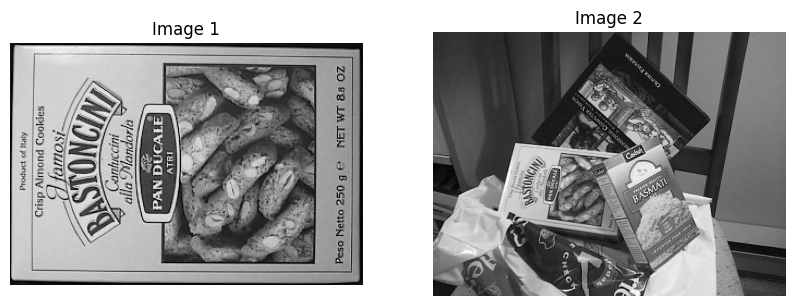

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('Image 1')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('Image 2')
plt.axis('off')
plt.show()

*Now Let's initialize the SIFT detector.*

In [ ]:
sift = cv2.SIFT_create()

*Find the keypoints and descriptors with SIFT.*


In [ ]:
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

*Find matches using k nearest neighbors.*

In [ ]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2) # So for each descriptor in image1, the algorithm finds the: best match , second best match. m = best match, n = second best match. 
# Each match contains : 
# m.distance     → similarity distance
# m.queryIdx     → index of keypoint in image1
# m.trainIdx     → index of keypoint in image2

This creates a Brute Force Matcher.

Purpose: Compare every descriptor from image 1 with every descriptor from image 2.

It finds the most similar descriptors.

Descriptors (des1, des2) are vectors describing keypoints detected by SIFT.

For SIFT:

each descriptor = 128-dimensional vector

similarity is measured with Euclidean distance
Smaller distance → more similar features.

*Apply ratio test to threshold the best matches.*

In [ ]:
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append([m])

A match is good only if the best match is much better than the second best.

Why?

If both distances are similar, the feature is ambiguous.

If the best match is clearly closer, the match is reliable.

*Draw* the matches.

In [ ]:
img3 = cv2.drawMatchesKnn(
    img1, kp1, img2, kp2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

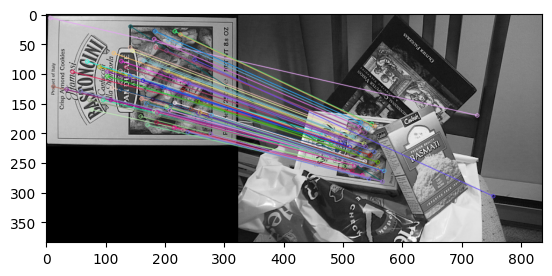

In [ ]:
plt.imshow(img3)

**Local Feature Matching with Transformers (LoFTR)**

In [ ]:
!pip install kornia  kornia-rs  kornia_moons opencv-python --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.4 MB/s eta 0:00:00


In [ ]:
import cv2
import kornia as K
import kornia.feature as KF
import matplotlib.pyplot as plt
import numpy as np
import torch
from kornia_moons.viz import draw_LAF_matches

In [ ]:
import io

import requests


def download_image(url: str, filename: str = "") -> str:
    filename = url.split("/")[-1] if len(filename) == 0 else filename
    # Download
    bytesio = io.BytesIO(requests.get(url).content)
    # Save file
    with open(filename, "wb") as outfile:
        outfile.write(bytesio.getbuffer())

    return filename

In [ ]:
url_a = "https://github.com/kornia/data/raw/main/matching/kn_church-2.jpg"
url_b = "https://github.com/kornia/data/raw/main/matching/kn_church-8.jpg"

download_image(url_a)
download_image(url_b)

'kn_church-8.jpg'

In [ ]:
from kornia.feature import LoFTR

img1 = K.io.load_image('/content/kn_church-2.jpg', K.io.ImageLoadType.RGB32)[None, ...]
img2 = K.io.load_image('/content/kn_church-8.jpg',K.io.ImageLoadType.RGB32)[None, ...]

img1 = K.geometry.resize(img1, (512, 512), antialias=True)
img2 = K.geometry.resize(img2, (512, 512), antialias=True)

Indicate whether the image is an "indoor" or "outdoor" image.

In [ ]:
matcher = LoFTR(pretrained="outdoor")

Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:02<00:00, 19.5MB/s]


LoFTR only works on grayscale images, so convert to images to grayscale.

In [ ]:
input_dict = {
    "image0": K.color.rgb_to_grayscale(img1),
    "image1": K.color.rgb_to_grayscale(img2),
}

Let's perform the inference.

In [ ]:
with torch.inference_mode():
    correspondences = matcher(input_dict)

Clean up the correspondences using Random Sample Consensus (RANSAC). This helps to deal with noise or outliers in the data.

In [ ]:
mkpts0 = correspondences["keypoints0"].cpu().numpy()
mkpts1 = correspondences["keypoints1"].cpu().numpy()
Fm, inliers = cv2.findFundamentalMat(mkpts0, mkpts1, cv2.USAC_MAGSAC, 0.5, 0.999, 100000)
inliers = inliers > 0

The fundamental matrix F describes the epipolar geometry between two cameras.
a point in image 1 corresponds to an epipolar line in image 2.
Because not all matches from LoFTR are correct.

So we use robust estimation to remove outliers.

Finally, we can visualize the matches.

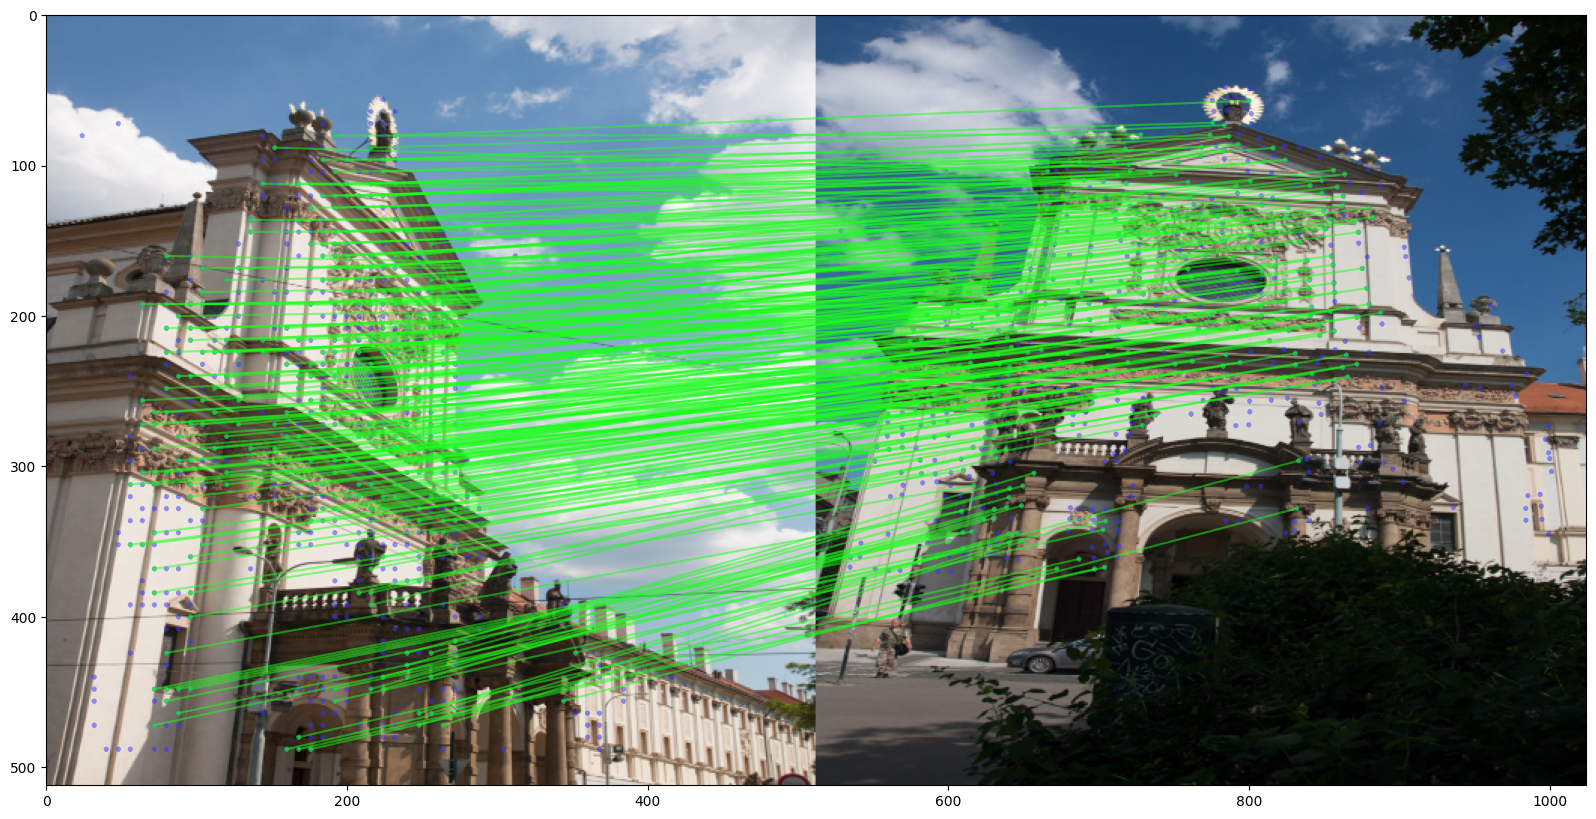

In [ ]:
draw_LAF_matches(
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts0).view(1, -1, 2),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1),
    ),
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts1).view(1, -1, 2),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1),
    ),
    torch.arange(mkpts0.shape[0]).view(-1, 1).repeat(1, 2),
    K.tensor_to_image(img1),
    K.tensor_to_image(img2),
    inliers,
    draw_dict={
        "inlier_color": (0.1, 1, 0.1, 0.5),
        "tentative_color": None,
        "feature_color": (0.2, 0.2, 1, 0.5),
        "vertical": False,
    },
)